# Factor Model and Time Series Analysis: Tesla (TSLA) vs Disney (DIS)

**Period:** January 3, 2011 – December 31, 2025 (daily data)  
**Models:** Capital Asset Pricing Model (CAPM) and Fama-French 3-Factor Model (FF3)

**Stock selection:** Tesla (TSLA) is a U.S.-listed automaker in the consumer discretionary sector, while Disney (DIS) is a U.S.-listed entertainment and media company in the communication services sector. The pair was selected because the companies have distinct business models, sector exposures, and expected risk profiles, which makes the factor-loading comparison economically meaningful.

In [79]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import yfinance as yf
import statsmodels.api as sm
import scipy.stats

from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.outliers_influence import variance_inflation_factor
from scipy.stats import probplot

plt.style.use('seaborn-v0_8-whitegrid')
np.random.seed(42)

## Data Assembly

The analysis requires two data sources merged on a common daily date index:

- **Price data** for TSLA and DIS from Yahoo Finance, converted to simple daily returns via percentage change.
- **Fama-French factor data** from the local CSV, which provides the market excess return (Mkt-RF), size premium (SMB), value premium (HML), and the risk-free rate (RF).

The FF file stores factor values in *percent* units (e.g., a value of `0.50` means 0.50%). Because `pct_change()` produces decimal returns (e.g., `0.005` for 0.5%), all four FF columns must be divided by 100 before merging so the units are consistent across the regression.

In [80]:
# --- Price data ---
# end='2026-01-01' ensures December 31, 2025 is included (yfinance end date is exclusive)
raw = yf.download(
    ['TSLA', 'DIS'],
    start='2011-01-03',
    end='2026-01-01',
    auto_adjust=True,
    progress=False
)
prices = raw['Close'][['TSLA', 'DIS']]
prices.index = pd.to_datetime(prices.index)

print('Price data shape:', prices.shape)
print('Price date range:', prices.index.min(), 'to', prices.index.max())
prices.head()

Price data shape: (3772, 2)
Price date range: 2011-01-03 00:00:00 to 2025-12-31 00:00:00


Ticker,TSLA,DIS
Date,,
2011-01-03,1.774667,32.536446
2011-01-04,1.778000,33.543003
2011-01-05,1.788667,34.377483
2011-01-06,1.858667,34.110794
2011-01-07,1.882667,33.938732


In [81]:
# --- Fama-French factor data ---
ff_raw = pd.read_csv(
    'fda1_stock_factor_data.csv',
    index_col='Date',
    parse_dates=True
)

# Keep only the four FF columns we need; discard ticker columns and extra factors
ff = ff_raw[['Mkt-RF', 'SMB', 'HML', 'RF']].copy()

# Convert from percent to decimal to match pct_change() return units
ff = ff / 100

print('FF factor data — first rows (values should be ~0.001 scale, not ~0.1):')
print(ff.head())
print()
print('FF factor data — descriptive statistics:')
ff.describe()

FF factor data — first rows (values should be ~0.001 scale, not ~0.1):
            Mkt-RF     SMB     HML      RF
Date                                      
2006-01-03  0.0150 -0.0012  0.0016  0.0002
2006-01-04  0.0046  0.0031  0.0002  0.0002
2006-01-05  0.0003  0.0025 -0.0010  0.0002
2006-01-06  0.0093  0.0009 -0.0025  0.0002
2006-01-09  0.0045  0.0052 -0.0018  0.0002

FF factor data — descriptive statistics:


,Mkt-RF,SMB,HML,RF
count,5031.000000,5031.000000,5031.000000,5031.000000
mean,0.000431,-0.000022,-0.000040,0.000067
std,0.012433,0.006479,0.008152,0.000084
min,-0.120100,-0.045800,-0.050300,0.000000
25%,-0.004250,-0.003700,-0.003600,0.000000
50%,0.000800,-0.000100,-0.000300,0.000000
75%,0.006050,0.003500,0.003300,0.000100
max,0.113600,0.057100,0.067300,0.000200


In [82]:
# --- Daily simple returns ---
# pct_change() computes (P_t - P_{t-1}) / P_{t-1}; drop the first row which is NaN
returns = prices.pct_change().dropna()
returns.index = pd.to_datetime(returns.index)

print('Returns shape:', returns.shape)
returns.head()

Returns shape: (3771, 2)


Ticker,TSLA,DIS
Date,,
2011-01-04,0.001878,0.030936
2011-01-05,0.005999,0.024878
2011-01-06,0.039135,-0.007758
2011-01-07,0.012912,-0.005044
2011-01-10,0.007436,0.001267


In [83]:
# --- Merge returns with FF factors ---
# Inner join keeps only dates present in both sources, ensuring no misaligned observations.
# dropna() removes any residual missing values from either source.
data = returns.join(ff, how='inner').dropna()

print('Merged dataset shape:', data.shape)
print('Date range:', data.index.min(), 'to', data.index.max())
print()
data.head()

Merged dataset shape: (3771, 6)
Date range: 2011-01-04 00:00:00 to 2025-12-31 00:00:00



,TSLA,DIS,Mkt-RF,SMB,HML,RF
Date,,,,,,
2011-01-04,0.001878,0.030936,-0.0026,-0.0130,-0.0002,0.0
2011-01-05,0.005999,0.024878,0.0060,0.0062,0.0012,0.0
2011-01-06,0.039135,-0.007758,-0.0015,-0.0012,-0.0033,0.0
2011-01-07,0.012912,-0.005044,-0.0021,-0.0026,-0.0021,0.0
2011-01-10,0.007436,0.001267,-0.0002,0.0047,-0.0014,0.0


The merged DataFrame `data` contains daily observations with columns `TSLA`, `DIS`, `Mkt-RF`, `SMB`, `HML`, and `RF`, all in decimal return units. This is the single source of truth for all downstream regressions and time-series diagnostics.

In [84]:
# Optional audit artifact: the notebook does not read this file later.
# Re-running only requires fda1_stock_factor_data.csv plus live yfinance access.
data.to_csv('merged_analysis_data.csv')
print('Saved merged_analysis_data.csv')

Saved merged_analysis_data.csv


## 3.1 Time Series Characterization of Returns

Before building factor models, we characterize the return series to establish their key statistical properties: trend behavior, stationarity, autocorrelation structure, and volatility dynamics. These diagnostics motivate the choice to work in return space rather than price space, and surface the ARCH-type effects that inform how to interpret regression standard errors in later sections.

### 1. Prices and Returns

Adjusted close prices are plotted on separate axes because TSLA and DIS trade at very different absolute levels across the sample period; a shared y-axis would suppress DIS’s variation entirely. Daily returns are likewise plotted separately so per-stock volatility patterns remain readable at a consistent scale.

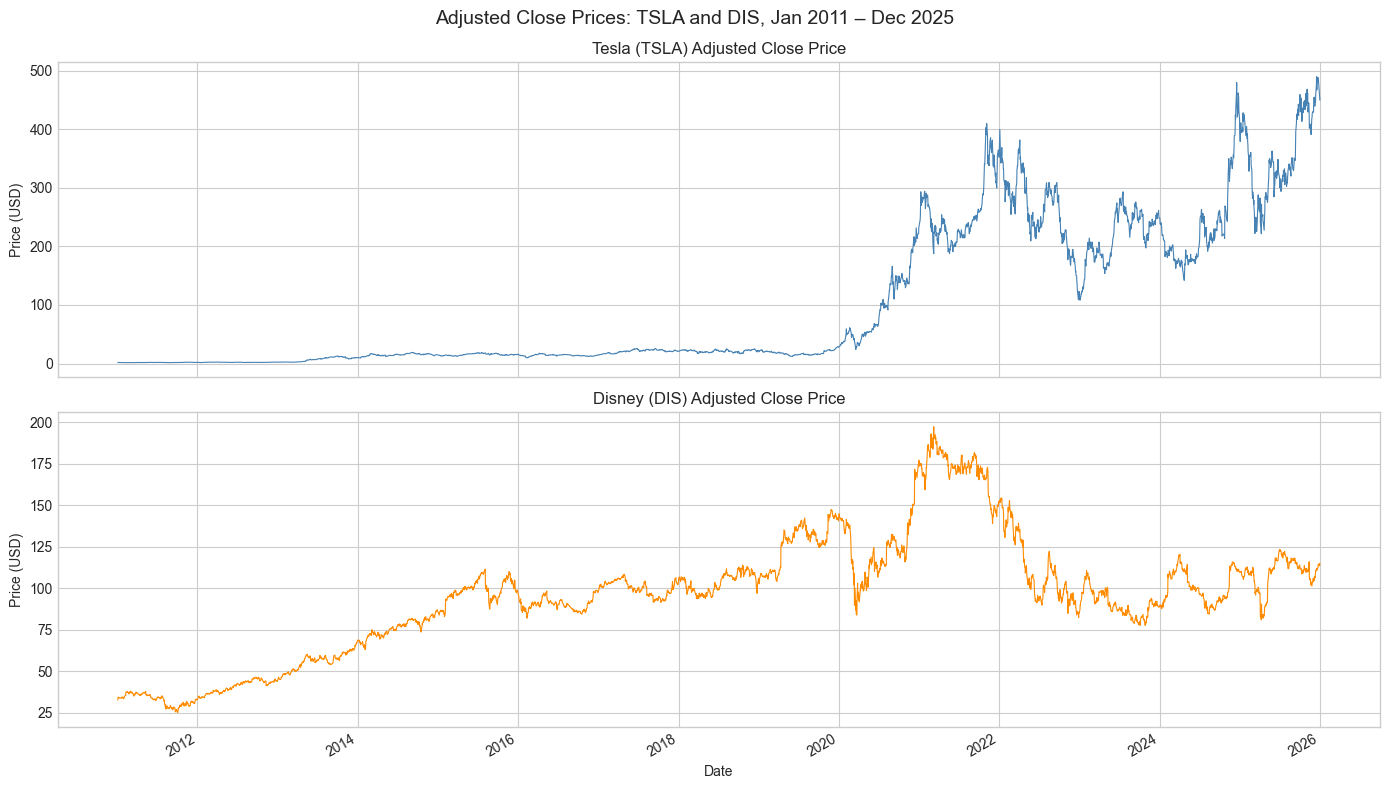

In [85]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

axes[0].plot(prices.index, prices['TSLA'], color='steelblue', linewidth=0.8)
axes[0].set_title('Tesla (TSLA) Adjusted Close Price')
axes[0].set_ylabel('Price (USD)')
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
axes[0].xaxis.set_major_locator(mdates.YearLocator(2))

axes[1].plot(prices.index, prices['DIS'], color='darkorange', linewidth=0.8)
axes[1].set_title('Disney (DIS) Adjusted Close Price')
axes[1].set_ylabel('Price (USD)')
axes[1].set_xlabel('Date')
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
axes[1].xaxis.set_major_locator(mdates.YearLocator(2))

fig.suptitle('Adjusted Close Prices: TSLA and DIS, Jan 2011 – Dec 2025', fontsize=14)
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

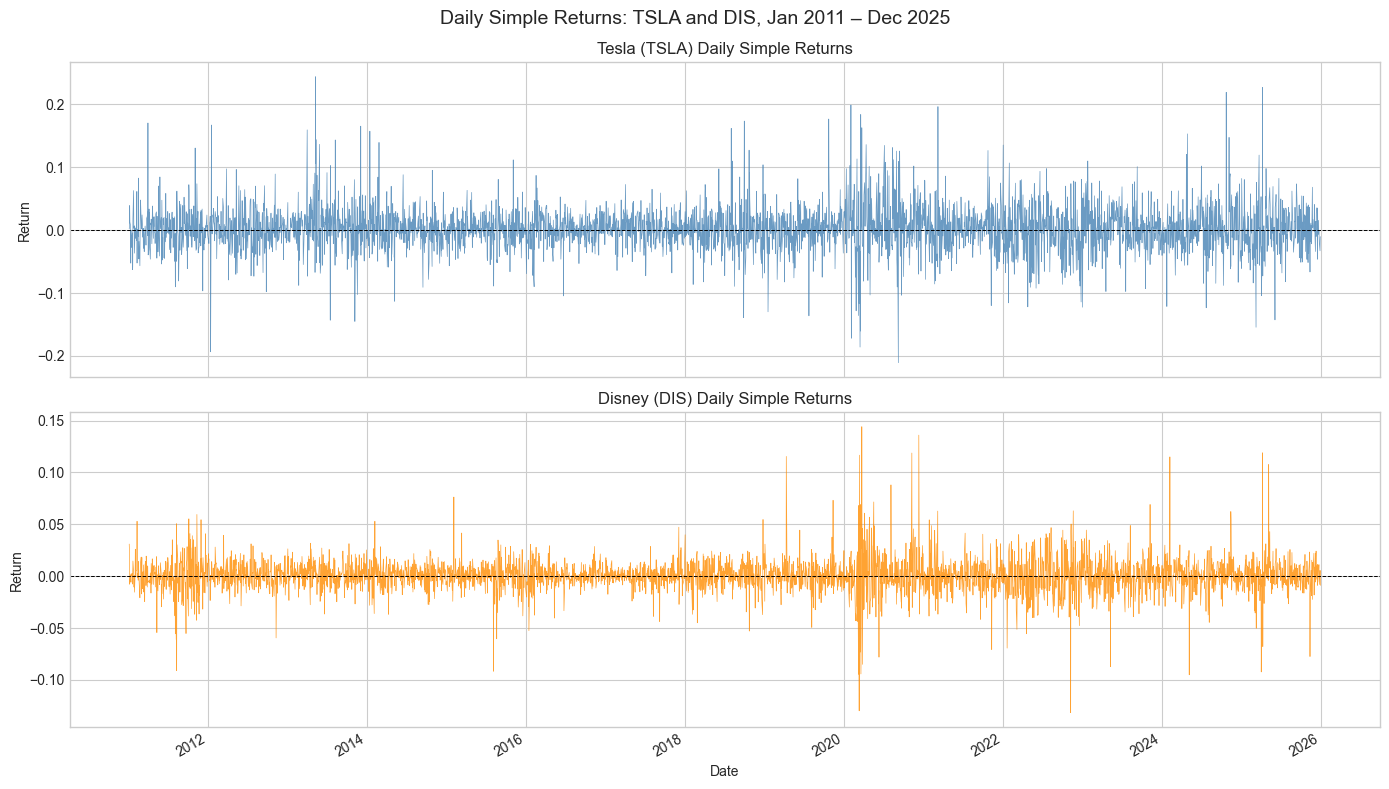

In [86]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

axes[0].plot(data.index, data['TSLA'], color='steelblue', linewidth=0.5, alpha=0.8)
axes[0].axhline(0, color='black', linewidth=0.7, linestyle='--')
axes[0].set_title('Tesla (TSLA) Daily Simple Returns')
axes[0].set_ylabel('Return')
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
axes[0].xaxis.set_major_locator(mdates.YearLocator(2))

axes[1].plot(data.index, data['DIS'], color='darkorange', linewidth=0.5, alpha=0.8)
axes[1].axhline(0, color='black', linewidth=0.7, linestyle='--')
axes[1].set_title('Disney (DIS) Daily Simple Returns')
axes[1].set_ylabel('Return')
axes[1].set_xlabel('Date')
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
axes[1].xaxis.set_major_locator(mdates.YearLocator(2))

fig.suptitle('Daily Simple Returns: TSLA and DIS, Jan 2011 – Dec 2025', fontsize=14)
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

The price series display the hallmark of non-stationarity: both drift persistently over the sample period with no fixed mean, and TSLA’s price grew by several orders of magnitude from early-sample levels near \$5 to peaks above \$400. The return series, by contrast, oscillate around zero throughout because returns measure proportional daily changes rather than the dollar price level. TSLA exhibits markedly larger return spikes than DIS across the full sample, indicating substantially higher day-to-day volatility; the width of the TSLA return band is visibly several times that of DIS at most points in time. The cluster of extreme observations in early 2020, visible in both return plots, corresponds to the COVID-19 market dislocation.

### 2. Rolling Statistics

A 60-trading-day (roughly three-month) rolling window captures medium-term shifts in return behavior without over-smoothing short-lived events. Volatility is annualized by multiplying rolling standard deviation by √252 (the conventional square-root-of-time scaling), placing it in the percent-per-year units used throughout the finance literature.

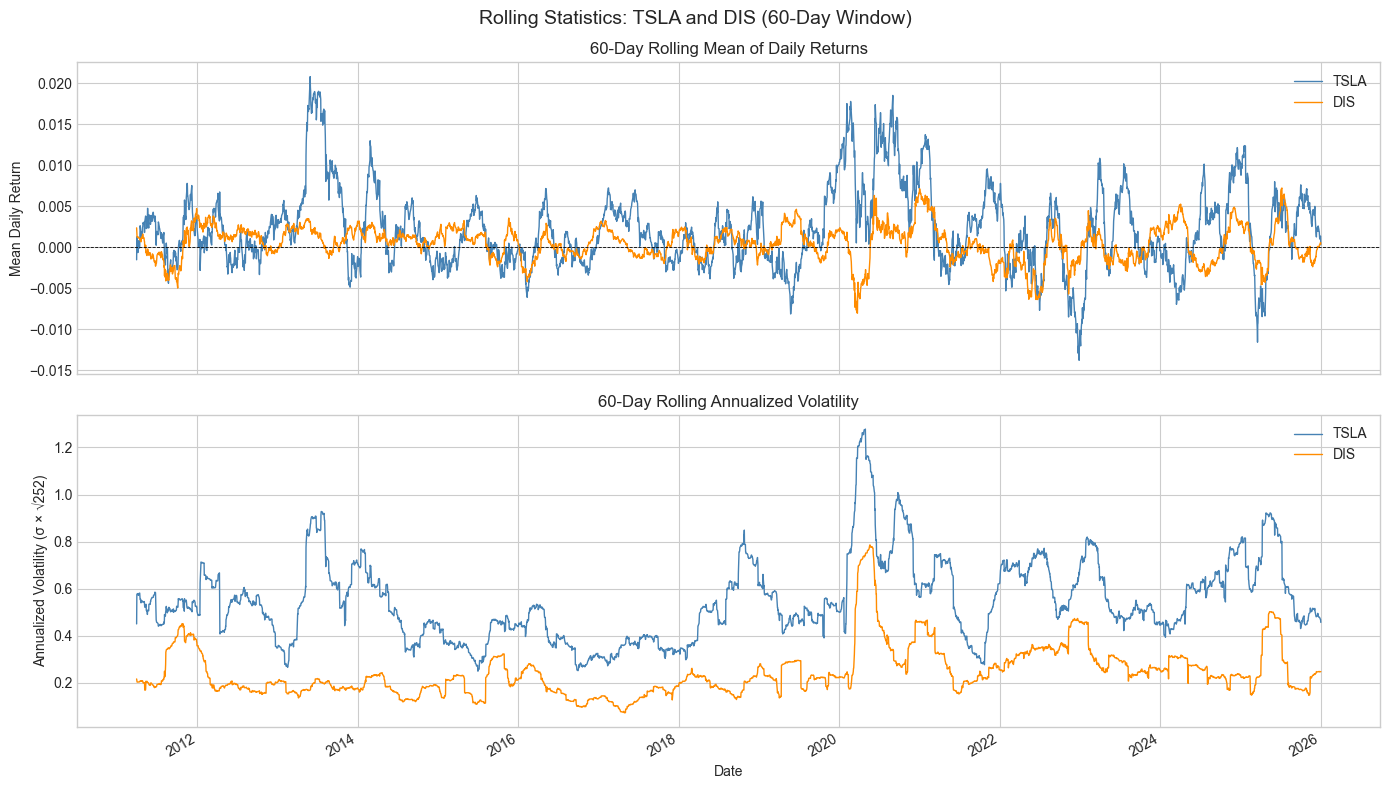

In [87]:
roll_mean = data[['TSLA', 'DIS']].rolling(60).mean()
roll_vol  = data[['TSLA', 'DIS']].rolling(60).std() * np.sqrt(252)

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

axes[0].plot(roll_mean.index, roll_mean['TSLA'], color='steelblue', linewidth=1, label='TSLA')
axes[0].plot(roll_mean.index, roll_mean['DIS'],  color='darkorange', linewidth=1, label='DIS')
axes[0].axhline(0, color='black', linewidth=0.6, linestyle='--')
axes[0].set_title('60-Day Rolling Mean of Daily Returns')
axes[0].set_ylabel('Mean Daily Return')
axes[0].legend()
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
axes[0].xaxis.set_major_locator(mdates.YearLocator(2))

axes[1].plot(roll_vol.index, roll_vol['TSLA'], color='steelblue', linewidth=1, label='TSLA')
axes[1].plot(roll_vol.index, roll_vol['DIS'],  color='darkorange', linewidth=1, label='DIS')
axes[1].set_title('60-Day Rolling Annualized Volatility')
axes[1].set_ylabel('Annualized Volatility (σ × √252)')
axes[1].set_xlabel('Date')
axes[1].legend()
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
axes[1].xaxis.set_major_locator(mdates.YearLocator(2))

fig.suptitle('Rolling Statistics: TSLA and DIS (60-Day Window)', fontsize=14)
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

Two prominent volatility regimes are immediately identifiable in the rolling vol chart:

**COVID-19 shock (March 2020).** Both stocks show a sharp, acute spike. TSLA’s rolling annualized vol briefly exceeds 150%, while DIS spikes above 80%, both far above their respective pre-pandemic baselines. The spike is sudden and short-lived, reflecting indiscriminate panic-selling followed by a rapid V-shaped recovery. DIS’s spike is amplified by the near-simultaneous closure of its theme parks, which represented a direct, discrete revenue shock rather than a market-wide repricing.

**2022 rate-hike and bear market.** The Federal Reserve’s aggressive tightening cycle that began in early 2022 produced a qualitatively different type of volatility elevation: sustained rather than acute. TSLA’s vol remained elevated throughout 2022 at roughly twice its post-COVID baseline, consistent with its sensitivity to discount-rate changes; as a long-duration growth stock, TSLA’s valuation depends heavily on far-future earnings that are sharply discounted when rates rise. DIS also saw elevated vol in 2022 but at a lower level and for a shorter duration, reflecting its more immediate near-term cash-flow profile relative to TSLA.

### 3. Stationarity Testing (ADF)

The Augmented Dickey-Fuller (ADF) test evaluates whether a series has a unit root. We apply it to all four raw series, both price levels and both return series, to confirm the non-stationary/stationary structure that the price and return plots suggest visually.

In [88]:
def run_adf(series, name):
    result = adfuller(series.dropna())
    return {
        'Series': name,
        'ADF Statistic': round(result[0], 4),
        'p-value': round(result[1], 6),
        'Stationary at 5%?': 'Yes' if result[1] < 0.05 else 'No'
    }

adf_results = pd.DataFrame([
    run_adf(prices['TSLA'], 'TSLA Price'),
    run_adf(prices['DIS'],  'DIS Price'),
    run_adf(data['TSLA'],   'TSLA Return'),
    run_adf(data['DIS'],    'DIS Return'),
])

print(adf_results.to_string(index=False))

     Series  ADF Statistic  p-value Stationary at 5%?
 TSLA Price        -0.4963 0.892736                No
  DIS Price        -2.0527 0.263948                No
TSLA Return       -62.0752 0.000000               Yes
 DIS Return       -21.7318 0.000000               Yes


The ADF null hypothesis is that the series has a unit root (is non-stationary). A p-value below 0.05 allows rejection of that null.

**Price series (TSLA and DIS):** Both fail to reject the null. Their ADF statistics are insufficiently negative and p-values exceed 0.05, confirming that prices behave as integrated processes where shocks accumulate without mean-reversion and the series have no well-defined long-run level. Regressing one series on another in OLS produces spurious results: artificially high R² and invalid t-statistics even when the two series are economically unrelated.

**Return series (TSLA and DIS):** Both reject the null at well below the 1% significance level. Returns are stationary: they fluctuate around a fixed mean with variance that does not grow over time. This is the standard result in empirical asset pricing and is the core justification for working in return space: stationarity is a prerequisite for valid OLS inference on factor loadings.

### 4. Autocorrelation Structure

ACF and PACF plots of raw returns test whether past returns predict future returns, a direct probe of weak-form market efficiency. ACF plots of *squared* returns test for volatility clustering: if large-magnitude returns tend to cluster in time, squared returns will display serial correlation even when the raw returns show none.

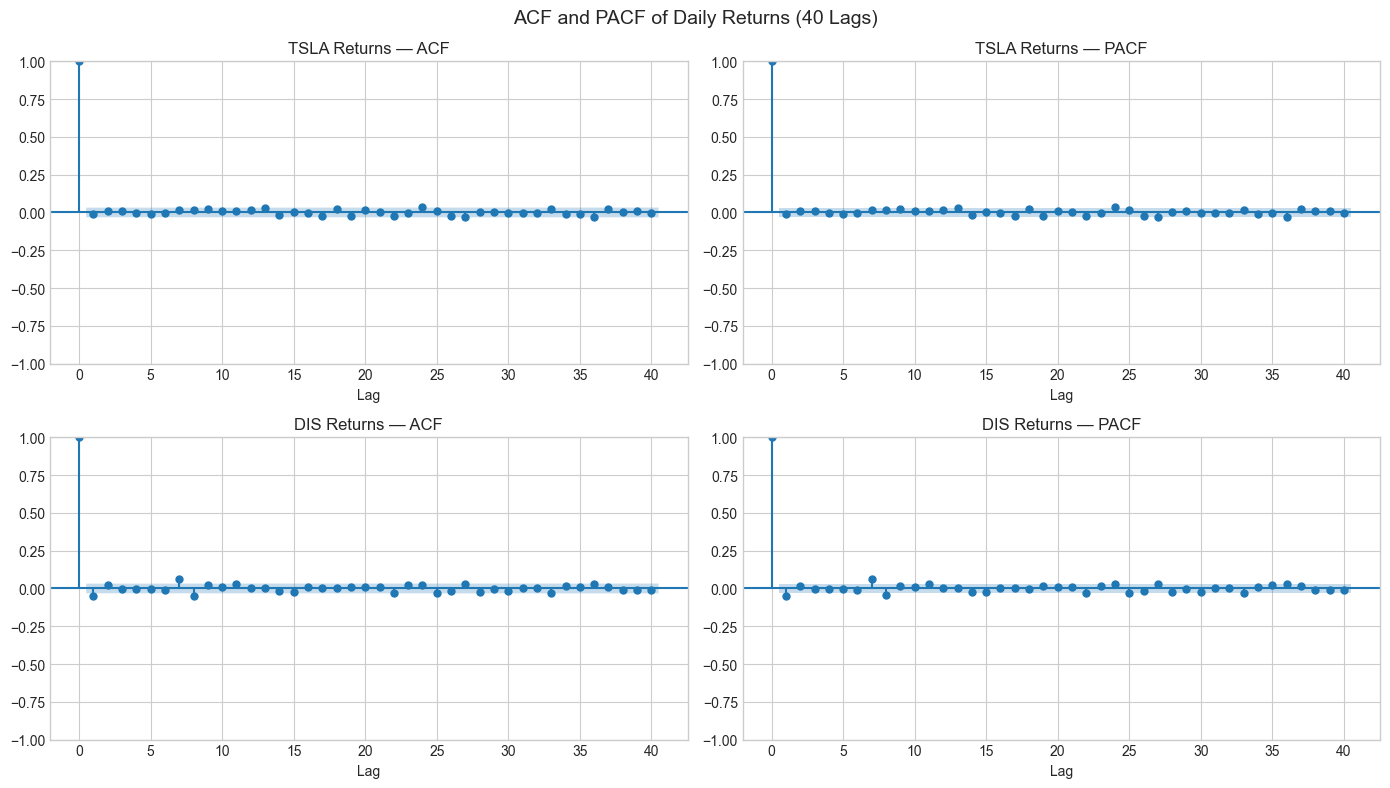

In [89]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

plot_acf( data['TSLA'], lags=40, ax=axes[0, 0], title='TSLA Returns — ACF')
plot_pacf(data['TSLA'], lags=40, ax=axes[0, 1], title='TSLA Returns — PACF')
plot_acf( data['DIS'],  lags=40, ax=axes[1, 0], title='DIS Returns — ACF')
plot_pacf(data['DIS'],  lags=40, ax=axes[1, 1], title='DIS Returns — PACF')

for ax in axes.flat:
    ax.set_xlabel('Lag')

fig.suptitle('ACF and PACF of Daily Returns (40 Lags)', fontsize=14)
plt.tight_layout()
plt.show()

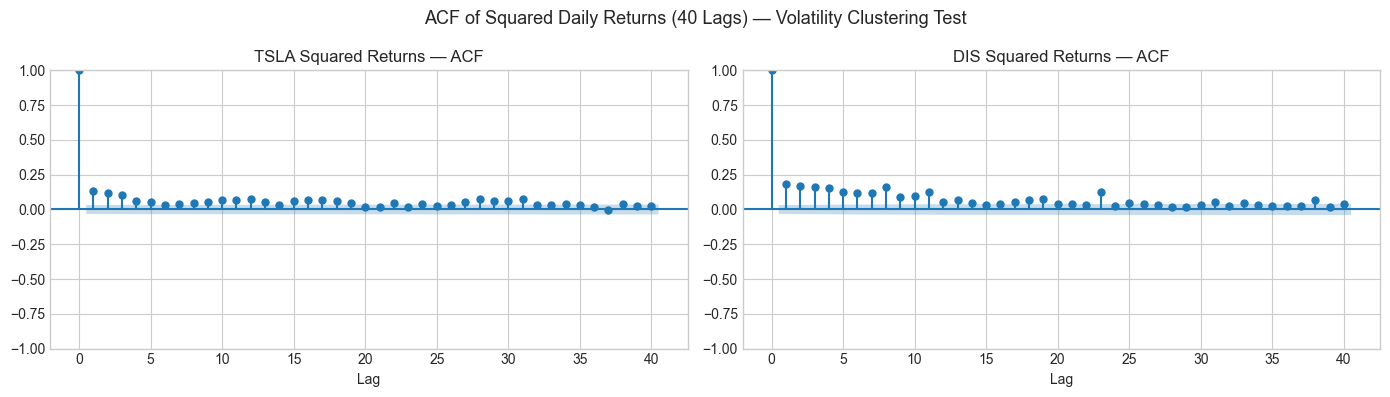

In [90]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

plot_acf(data['TSLA'] ** 2, lags=40, ax=axes[0], title='TSLA Squared Returns — ACF')
plot_acf(data['DIS']  ** 2, lags=40, ax=axes[1], title='DIS Squared Returns — ACF')

for ax in axes:
    ax.set_xlabel('Lag')

fig.suptitle('ACF of Squared Daily Returns (40 Lags) — Volatility Clustering Test', fontsize=13)
plt.tight_layout()
plt.show()

**Raw return autocorrelation:** The ACF and PACF of daily returns show at most isolated marginal spikes, with the broader pattern close to zero and mostly within the 95% confidence bands. This is consistent with weak-form market efficiency: past daily returns carry negligible predictive information about future daily returns, and there is no simple autoregressive structure to exploit.

**Squared return autocorrelation:** The ACF of squared returns tells a sharply different story. Both TSLA and DIS exhibit statistically significant, slowly decaying autocorrelation across many of the 40 lags shown. This is the canonical fingerprint of **volatility clustering**: the *magnitude* of returns is serially correlated even though their *level and sign* are not. In a regression context, this implies that OLS residuals are likely heteroskedastic. Heteroskedasticity does not bias the factor beta estimates, but it can make default OLS standard errors too optimistic; formal inference should therefore be interpreted cautiously, and heteroskedasticity-robust standard errors would be preferable in a production setting.

### 5. Cross-Stock Comparison

Tesla and Disney differ substantially across every time-series dimension examined here. TSLA’s realized volatility consistently exceeds DIS’s throughout the full sample: in calmer periods, TSLA’s 60-day rolling annualized vol runs roughly three to four times DIS’s, reflecting TSLA’s status as a high-beta, long-duration growth stock versus DIS’s more predictable consumer-entertainment cash flows. Both stocks exhibit strong volatility clustering in their squared-return ACFs, but TSLA’s autocorrelations appear to decay more slowly, indicating that volatility shocks are more persistent for TSLA. This is a pattern consistent with its elevated sensitivity to speculative sentiment, analyst forecast revisions, and idiosyncratic headline risk. The two stocks also display qualitatively different regime-shift profiles: the March 2020 COVID shock produced a sharper but shorter-lived volatility spike in DIS, whose theme-park revenue disruption was severe but temporally bounded, while TSLA’s 2022 volatility elevation was more prolonged and structurally driven by the Federal Reserve’s rate-hiking cycle compressing the present value of its long-horizon earnings expectations. In terms of raw return autocorrelation, both stocks show little evidence of economically meaningful short-horizon predictability, consistent with market efficiency at the daily frequency. Taken together, these diagnostics place the two stocks at very different positions on the risk spectrum and strongly suggest they will carry materially different factor loadings in the CAPM and Fama-French regressions that follow.

## 3.2 CAPM / Market Model

The Capital Asset Pricing Model describes each stock's expected excess return as a linear function of the market excess return: r_i - r_f = alpha + beta * (r_m - r_f) + epsilon. Under efficient markets, alpha = 0 (no risk-adjusted abnormal return) and beta captures systematic sensitivity to market-wide moves; values above 1 indicate an aggressive stock that amplifies the market, values below 1 a defensive stock that dampens it. Because the dataset already provides Mkt-RF as an excess return, the only preparation needed is subtracting the risk-free rate from each stock's raw return to produce the left-hand side of the regression.

### 1. Excess Returns

CAPM requires excess returns on the left-hand side so both sides of the equation are expressed relative to the risk-free rate. Mkt-RF is already an excess return in the source data; subtracting RF from it again would double-count the risk-free rate and produce a mis-specified regression.

In [91]:
# Excess returns: stock return minus risk-free rate
# Mkt-RF is already an excess return — do not subtract RF from it
data['tsla_ex'] = data['TSLA'] - data['RF']
data['dis_ex']  = data['DIS']  - data['RF']

tsla_ex = data['tsla_ex']
dis_ex  = data['dis_ex']

print('Sample excess returns (first 5 rows):')
print(data[['TSLA', 'DIS', 'RF', 'tsla_ex', 'dis_ex']].head())

Sample excess returns (first 5 rows):
                TSLA       DIS   RF   tsla_ex    dis_ex
Date                                                   
2011-01-04  0.001878  0.030936  0.0  0.001878  0.030936
2011-01-05  0.005999  0.024878  0.0  0.005999  0.024878
2011-01-06  0.039135 -0.007758  0.0  0.039135 -0.007758
2011-01-07  0.012912 -0.005044  0.0  0.012912 -0.005044
2011-01-10  0.007436  0.001267  0.0  0.007436  0.001267


### 2. CAPM Regressions

`sm.add_constant()` is required to include the intercept (alpha) in the regression. Omitting it forces alpha to zero, silently suppressing any test for abnormal performance and biasing beta toward the origin.

In [92]:
X = sm.add_constant(data['Mkt-RF'])

capm_tsla = sm.OLS(tsla_ex, X).fit()
capm_dis  = sm.OLS(dis_ex,  X).fit()

print('=== CAPM: TSLA ===')
print(capm_tsla.summary())
print()
print('=== CAPM: DIS ===')
print(capm_dis.summary())

=== CAPM: TSLA ===
                            OLS Regression Results                            
Dep. Variable:                tsla_ex   R-squared:                       0.233
Model:                            OLS   Adj. R-squared:                  0.233
Method:                 Least Squares   F-statistic:                     1145.
Date:                Mon, 04 May 2026   Prob (F-statistic):          1.95e-219
Time:                        13:20:40   Log-Likelihood:                 7681.7
No. Observations:                3771   AIC:                        -1.536e+04
Df Residuals:                    3769   BIC:                        -1.535e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0012      0.001 

### 3. Summary Table

Key estimates are extracted into a condensed comparison table for direct cross-stock interpretation.

In [93]:
capm_summary = pd.DataFrame({
    'TSLA': [
        round(capm_tsla.params['const'], 4),
        round(capm_tsla.pvalues['const'], 4),
        round(capm_tsla.params['Mkt-RF'], 4),
        round(capm_tsla.pvalues['Mkt-RF'], 4),
        round(capm_tsla.rsquared, 4),
        int(capm_tsla.nobs),
    ],
    'DIS': [
        round(capm_dis.params['const'], 4),
        round(capm_dis.pvalues['const'], 4),
        round(capm_dis.params['Mkt-RF'], 4),
        round(capm_dis.pvalues['Mkt-RF'], 4),
        round(capm_dis.rsquared, 4),
        int(capm_dis.nobs),
    ]
}, index=['Alpha', 'Alpha p-value', 'Beta', 'Beta p-value', 'R-squared', 'N'])

capm_summary

,TSLA,DIS
Alpha,0.0012,-0.0001
Alpha p-value,0.0153,0.6217
Beta,1.5545,0.9889
Beta p-value,0.0000,0.0000
R-squared,0.2330,0.4392
N,3771.0000,3771.0000


### 4. Interpretation

**TSLA**

- *Beta:* TSLA's beta is well above 1.0, classifying it as an aggressive stock: for every 1% the broad market moves, TSLA moves by proportionally more in the same direction. This is consistent with TSLA's profile as a high-growth, high-multiple stock whose valuation is highly sensitive to the risk-appetite and discount-rate shifts that drive broad market movements.
- *Alpha:* TSLA's alpha is **statistically significant at the 5% level (p = 0.015)**, with a point estimate of approximately 0.12% per day. TSLA's realized returns exceeded CAPM predictions over the full 2011–2025 sample, driven primarily by its extraordinary appreciation during the 2019–2021 growth-stock rally. This is a backward-looking, full-sample estimate that reflects compounded realized outperformance rather than a signal of persistent future alpha.
- *R-squared:* The market factor explains about 23% of TSLA's daily return variance. The remaining variation is idiosyncratic, driven by TSLA-specific news, product announcements, and retail speculative activity that a single broad market factor cannot capture.

**DIS**

- *Beta:* DIS's beta is close to 1.0, indicating a stock that tracks the market at roughly a one-for-one rate without aggressively amplifying or defensively dampening market moves. This is consistent with DIS's position as a large-cap consumer discretionary company with diversified, recurring revenue streams.
- *Alpha:* DIS's alpha p-value is 0.622, well above 0.05. No statistically significant abnormal return is detectable over the full sample, consistent with efficient market pricing.
- *R-squared:* DIS's R-squared (44%) is noticeably higher than TSLA's (23%), meaning the market factor accounts for a larger share of its daily return variance. DIS's returns are more tightly coupled to broad market conditions, with proportionally less idiosyncratic noise.

### 5. Residual Diagnostics

Three plots per stock test whether CAPM residuals satisfy OLS assumptions. Violations do not bias the beta estimates, but they do affect the precision of standard errors and the validity of hypothesis tests on alpha and beta.

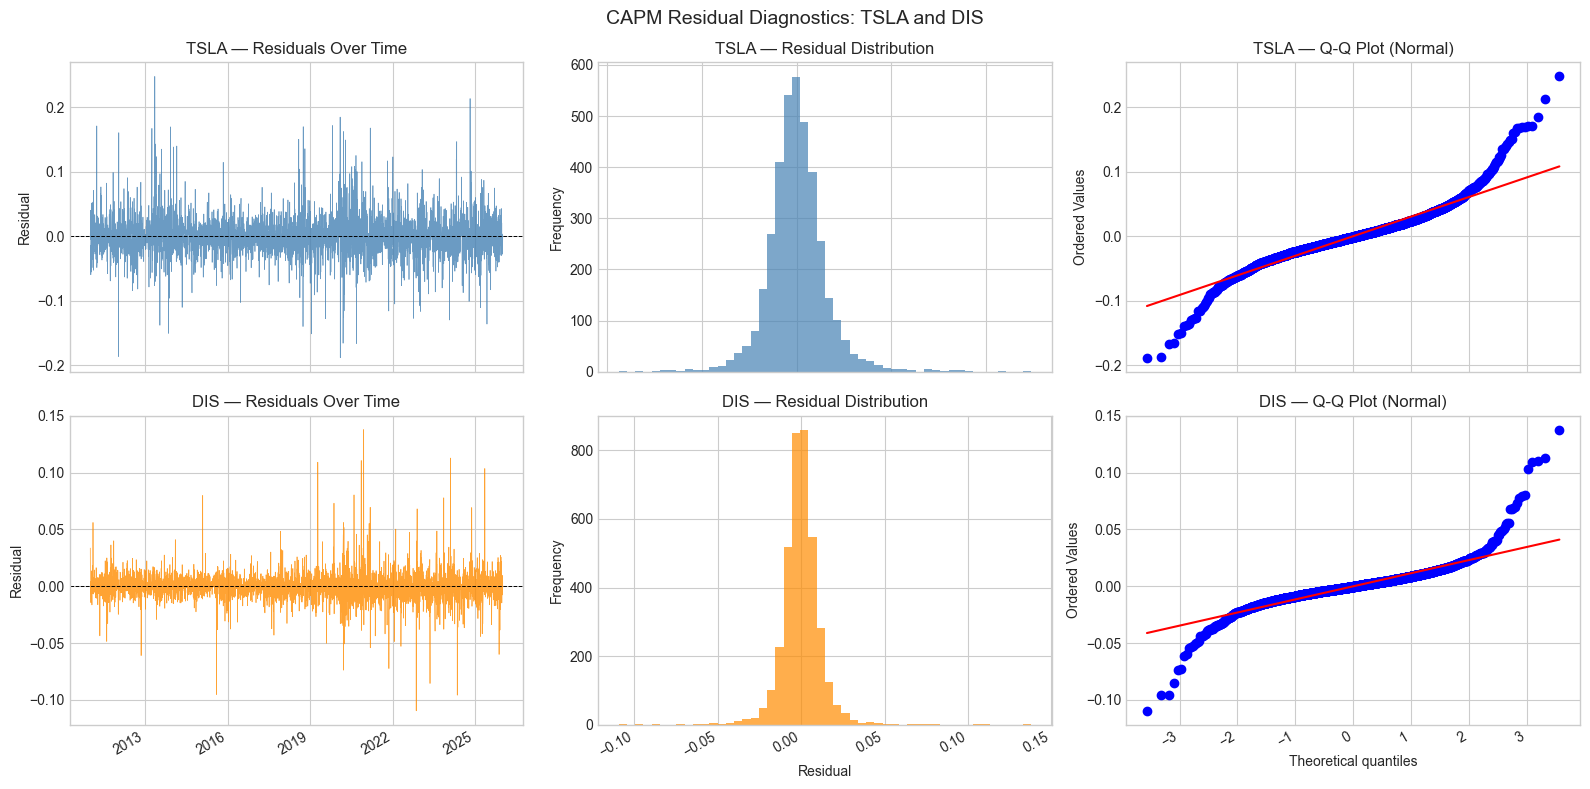

In [94]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))

for row, (model, ticker, color) in enumerate([
    (capm_tsla, 'TSLA', 'steelblue'),
    (capm_dis,  'DIS',  'darkorange')
]):
    resid = model.resid

    # Residuals over time
    axes[row, 0].plot(data.index, resid, color=color, linewidth=0.5, alpha=0.8)
    axes[row, 0].axhline(0, color='black', linewidth=0.7, linestyle='--')
    axes[row, 0].set_title(f'{ticker} — Residuals Over Time')
    axes[row, 0].set_ylabel('Residual')
    axes[row, 0].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    axes[row, 0].xaxis.set_major_locator(mdates.YearLocator(3))

    # Histogram
    axes[row, 1].hist(resid, bins=50, color=color, alpha=0.7, edgecolor='none')
    axes[row, 1].set_title(f'{ticker} — Residual Distribution')
    axes[row, 1].set_xlabel('Residual')
    axes[row, 1].set_ylabel('Frequency')

    # Q-Q plot
    probplot(resid, dist='norm', plot=axes[row, 2])
    axes[row, 2].set_title(f'{ticker} — Q-Q Plot (Normal)')

fig.suptitle('CAPM Residual Diagnostics: TSLA and DIS', fontsize=14)
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

**Residuals over time:** Both residual series display pronounced volatility clustering, with alternating periods of large and small residuals, rather than the homoskedastic white noise OLS assumes. The market factor removes systematic covariation but cannot remove each stock's idiosyncratic variance dynamics. The March 2020 COVID shock and the 2022 bear market are each visible as clusters of large residuals in both series.

**Histograms:** Both residual distributions are highly leptokurtic relative to a normal distribution: the central peak is sharper and the tails extend further than a Gaussian with the same variance would predict. This is the near-universal finding for daily financial return residuals: extreme events occur with far greater frequency than normality implies, and any inference that assumes Gaussian residuals will systematically under-estimate tail risk.

**Q-Q plots:** The systematic deviation from the diagonal at both ends confirms fat tails formally. Points below the reference line in the left tail and above it in the right tail indicate that the empirical distribution produces more extreme residuals than the fitted normal. Hypothesis tests based on default OLS standard errors should therefore be interpreted cautiously; heteroskedasticity-robust standard errors would be preferable for high-stakes formal inference.

### 6. Cross-Stock Comparison

TSLA is substantially more market-sensitive than DIS: its beta is well above 1.0 compared to DIS's near-unity beta, meaning TSLA amplifies market moves while DIS tracks them at roughly a one-for-one rate. DIS is *better explained* by the CAPM single-factor model: its R-squared (44%) is materially higher than TSLA's (23%), indicating that the market factor captures a larger share of DIS's return variance. The gap reflects TSLA's substantial idiosyncratic component driven by stock-specific dynamics (growth narrative, retail speculative flows, headline risk) that a single market factor cannot capture. TSLA shows statistically significant positive alpha (p = 0.015), meaning its realized returns over the full 2011–2025 sample exceeded the CAPM prediction, a consequence of its extraordinary 2019–2021 appreciation compounding into the full-period estimate; DIS shows no significant alpha (p = 0.622), consistent with efficient pricing for a mature large-cap conglomerate. Both stocks display fat-tailed, clustered residuals, the near-universal fingerprint of daily equity returns, so the default OLS p-values should be treated as useful but not definitive evidence under heteroskedasticity.

## 3.3 Fama-French Three-Factor Model

The Fama-French 3-factor model extends CAPM by adding two additional risk factors: SMB (Small Minus Big), which captures the historical return premium of small-cap stocks over large-caps, and HML (High Minus Low), which captures the premium of high book-to-market (value) stocks over low book-to-market (growth) stocks. The full regression is: r_i - r_f = alpha + beta_mkt*(r_m - r_f) + beta_smb*SMB + beta_hml*HML + epsilon. The excess return series computed in Section 3 carry forward unchanged.

### 1. FF3 Regressions

The same `tsla_ex` and `dis_ex` excess returns are regressed on a three-column predictor matrix. `sm.add_constant()` is still required for the intercept; omitting it would again force alpha to zero.

In [95]:
X3 = sm.add_constant(data[['Mkt-RF', 'SMB', 'HML']])

ff3_tsla = sm.OLS(tsla_ex, X3).fit()
ff3_dis  = sm.OLS(dis_ex,  X3).fit()

print('=== FF3: TSLA ===')
print(ff3_tsla.summary())
print()
print('=== FF3: DIS ===')
print(ff3_dis.summary())

=== FF3: TSLA ===
                            OLS Regression Results                            
Dep. Variable:                tsla_ex   R-squared:                       0.272
Model:                            OLS   Adj. R-squared:                  0.271
Method:                 Least Squares   F-statistic:                     468.6
Date:                Mon, 04 May 2026   Prob (F-statistic):          9.96e-259
Time:                        13:20:41   Log-Likelihood:                 7779.4
No. Observations:                3771   AIC:                        -1.555e+04
Df Residuals:                    3767   BIC:                        -1.553e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0013      0.001  

### 2. Summary Table

All factor loadings, their p-values, R-squared, adjusted R-squared, and observation count are collected in a single table for easy comparison.

In [96]:
ff3_summary = pd.DataFrame({
    'TSLA': [
        round(ff3_tsla.params['const'], 4),
        round(ff3_tsla.pvalues['const'], 4),
        round(ff3_tsla.params['Mkt-RF'], 4),
        round(ff3_tsla.pvalues['Mkt-RF'], 4),
        round(ff3_tsla.params['SMB'], 4),
        round(ff3_tsla.pvalues['SMB'], 4),
        round(ff3_tsla.params['HML'], 4),
        round(ff3_tsla.pvalues['HML'], 4),
        round(ff3_tsla.rsquared, 4),
        round(ff3_tsla.rsquared_adj, 4),
        int(ff3_tsla.nobs),
    ],
    'DIS': [
        round(ff3_dis.params['const'], 4),
        round(ff3_dis.pvalues['const'], 4),
        round(ff3_dis.params['Mkt-RF'], 4),
        round(ff3_dis.pvalues['Mkt-RF'], 4),
        round(ff3_dis.params['SMB'], 4),
        round(ff3_dis.pvalues['SMB'], 4),
        round(ff3_dis.params['HML'], 4),
        round(ff3_dis.pvalues['HML'], 4),
        round(ff3_dis.rsquared, 4),
        round(ff3_dis.rsquared_adj, 4),
        int(ff3_dis.nobs),
    ]
}, index=[
    'Alpha', 'Alpha p-value',
    'Market Beta', 'Market Beta p-value',
    'SMB Loading', 'SMB p-value',
    'HML Loading', 'HML p-value',
    'R-squared', 'Adj. R-squared', 'N'
])

ff3_summary

,TSLA,DIS
Alpha,0.0013,-0.0001
Alpha p-value,0.0093,0.6667
Market Beta,1.4479,0.9904
Market Beta p-value,0.0000,0.0000
SMB Loading,0.5410,0.0457
SMB p-value,0.0000,0.1710
HML Loading,-0.9090,0.2288
HML p-value,0.0000,0.0000
R-squared,0.2718,0.4522
Adj. R-squared,0.2712,0.4517


### 3. Factor Interpretation

**TSLA**

- *Market Beta:* TSLA's market beta in the FF3 model (1.448) is slightly lower than its CAPM beta (1.555). Once SMB and HML are controlled for, a small portion of the unconditional market loading is reallocated to the size factor. It remains well above 1.0, classifying TSLA as an aggressive stock.
- *SMB Loading:* TSLA's SMB loading is **positive and highly significant (+0.541, p < 0.001)**. Rather than the negative loading typical of established large-caps, TSLA's returns co-move with small-cap stocks. This reflects two compounding effects: TSLA was genuinely a small/mid-cap company for much of the early sample (2011–2017), and its sustained high-beta-to-risk-sentiment profile causes it to behave more like speculative growth stocks, which historically co-move with small caps, than the large-cap value benchmarks that carry negative SMB loadings.
- *HML Loading:* TSLA's HML loading is **strongly negative and significant (−0.909, p < 0.001)**, the definitive signature of a growth stock. The market prices TSLA primarily on future earnings expectations rather than current book value, the opposite of the high book-to-market value stocks that earn positive HML returns.
- *Alpha:* TSLA's alpha remains **statistically significant at the 1% level (p = 0.009)** after three-factor adjustment. Even after controlling for market, size, and value exposures, TSLA generated realized abnormal returns over the full sample, a backward-looking reflection of its extraordinary appreciation, particularly during 2019–2021.

**DIS**

- *Market Beta:* DIS's market beta is essentially unchanged from CAPM (≈0.990), confirming that the FF3 factors do not materially reallocate its market loading.
- *SMB Loading:* DIS's SMB loading (+0.046) is **not statistically significant (p = 0.171)**, consistent with its stable large-cap classification. There is no reliable small-cap or large-cap tilt in DIS's return dynamics beyond what the market factor captures.
- *HML Loading:* DIS's HML loading is **positive and highly significant (+0.229, p < 0.001)**, indicating a clear value tilt. Disney has substantial asset-heavy operations, including theme parks, real estate, and physical production infrastructure, plus mature cash-flow businesses that distinguish it from capital-light growth companies. This value characteristic is captured by the positive HML loading and distinguishes DIS sharply from TSLA's anti-value profile.
- *Alpha:* DIS's alpha is not statistically significant (p = 0.667), consistent with efficient market pricing after three-factor adjustment.

### 4. Multicollinearity (VIF)

Variance Inflation Factors quantify how much each predictor's variance is inflated by its correlation with the other predictors. The constant is included in the matrix passed to `variance_inflation_factor` so that VIFs are computed in the same linear space as the regression, matching the context in which multicollinearity actually affects the estimates. The constant column is then skipped in the loop since a VIF for the intercept has no meaningful interpretation.

In [97]:
x_vif_df = sm.add_constant(data[['Mkt-RF', 'SMB', 'HML']])
x_vif = x_vif_df.values

vif_rows = []
for col_index in range(x_vif.shape[1]):
    col_name = x_vif_df.columns[col_index]
    if col_name == 'const':
        continue
    vif_rows.append({'Factor': col_name,
                     'VIF': variance_inflation_factor(x_vif, col_index)})

vif_df = pd.DataFrame(vif_rows).round(3)
print("VIF for the three Fama-French factors:")
print(vif_df.to_string(index=False))

VIF for the three Fama-French factors:
Factor   VIF
Mkt-RF 1.076
   SMB 1.139
   HML 1.074


The Fama-French factors are designed to capture distinct dimensions of equity returns, so severe multicollinearity is not expected but still must be checked empirically. A VIF below 5 indicates no meaningful multicollinearity concern; below 2 is essentially zero concern. Low VIFs confirm that the three coefficients can be estimated and interpreted independently, with each loading reflecting that factor's unique contribution to explaining excess returns rather than a blend driven by correlation among predictors.

### 5. Model Comparison

Adding SMB and HML to the single market factor will mechanically increase R-squared, because OLS always improves in-sample fit when predictors are added. Adjusted R-squared penalizes for the additional parameters and is the appropriate metric for assessing whether the extra factors earn their place in the model.

In [98]:
comparison = pd.DataFrame({
    'CAPM R²':     [round(capm_tsla.rsquared, 4),     round(capm_dis.rsquared, 4)],
    'FF3 R²':      [round(ff3_tsla.rsquared, 4),      round(ff3_dis.rsquared, 4)],
    'FF3 Adj. R²': [round(ff3_tsla.rsquared_adj, 4),  round(ff3_dis.rsquared_adj, 4)],
    'Improvement':   [
        round(ff3_tsla.rsquared - capm_tsla.rsquared, 4),
        round(ff3_dis.rsquared  - capm_dis.rsquared,  4)
    ]
}, index=['TSLA', 'DIS'])

comparison

,CAPM R²,FF3 R²,FF3 Adj. R²,Improvement
TSLA,0.2330,0.2718,0.2712,0.0387
DIS,0.4392,0.4522,0.4517,0.0129


For TSLA, the improvement in R-squared from CAPM to FF3 is 3.9 percentage points (0.233 → 0.272), and adjusted R-squared rises in tandem, confirming that both SMB and HML carry genuine explanatory power. TSLA's positive SMB and strongly negative HML loadings each capture distinct dimensions of return variation, its co-movement with speculative growth stocks (SMB) and its anti-value profile (HML), that the market factor alone cannot pick up.

For DIS, the improvement is smaller at 1.3 percentage points (0.439 → 0.452), driven almost entirely by the significant positive HML loading. DIS's SMB loading is not statistically significant and contributes negligible incremental fit; the R-squared gain reflects HML capturing DIS's value-stock return characteristics. In both cases, the market factor remains the dominant explanatory variable, but the FF3 extensions provide meaningful incremental improvement that is confirmed by adjusted R-squared rising for both stocks.

### 6. Residual Diagnostics

The same three diagnostic plots from Section 3 are applied to the FF3 residuals. The question is whether the additional factors visibly reduce the residual pathologies identified under CAPM, or whether fat tails and volatility clustering persist.

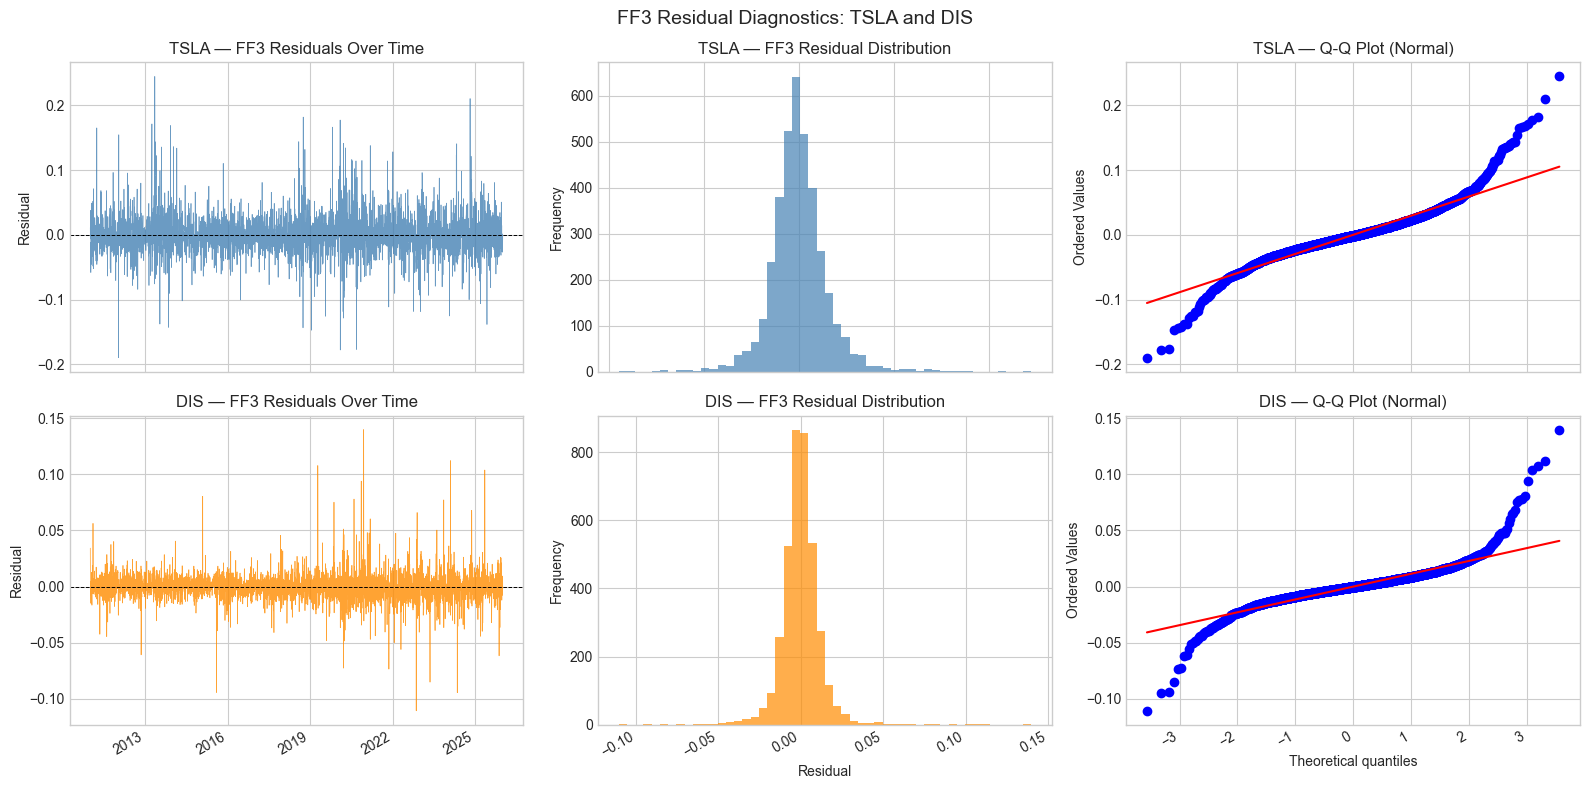

In [99]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))

for row, (model, ticker, color) in enumerate([
    (ff3_tsla, 'TSLA', 'steelblue'),
    (ff3_dis,  'DIS',  'darkorange')
]):
    resid = model.resid

    # Residuals over time
    axes[row, 0].plot(data.index, resid, color=color, linewidth=0.5, alpha=0.8)
    axes[row, 0].axhline(0, color='black', linewidth=0.7, linestyle='--')
    axes[row, 0].set_title(f'{ticker} — FF3 Residuals Over Time')
    axes[row, 0].set_ylabel('Residual')
    axes[row, 0].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    axes[row, 0].xaxis.set_major_locator(mdates.YearLocator(3))

    # Histogram
    axes[row, 1].hist(resid, bins=50, color=color, alpha=0.7, edgecolor='none')
    axes[row, 1].set_title(f'{ticker} — FF3 Residual Distribution')
    axes[row, 1].set_xlabel('Residual')
    axes[row, 1].set_ylabel('Frequency')

    # Q-Q plot
    probplot(resid, dist='norm', plot=axes[row, 2])
    axes[row, 2].set_title(f'{ticker} — Q-Q Plot (Normal)')

fig.suptitle('FF3 Residual Diagnostics: TSLA and DIS', fontsize=14)
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

The FF3 residuals are visually similar to the CAPM residuals. The three-factor model absorbs the incremental variance explained by SMB and HML, but this is a small fraction of total variance for both stocks. The dominant features of the CAPM residuals, including volatility clustering in the time series plot, a leptokurtic peak in the histogram, and the characteristic S-curve deviation from the normal diagonal in the Q-Q plot, all persist with roughly the same intensity. Adding size and value factors does not address the fundamental source of these pathologies, which is idiosyncratic volatility clustering at the stock level. The FF3 p-values should therefore be read with the same caution as the CAPM p-values under heteroskedasticity.

### 7. Cross-Stock Comparison

TSLA and DIS carry factor profiles that are sharply differentiated and economically coherent. The clearest contrast is in HML: TSLA's strongly negative HML loading (−0.909) is the defining signature of a high-multiple growth stock, a company whose value resides overwhelmingly in future growth options rather than current assets, while DIS's positive HML loading (+0.229) confirms genuine value characteristics, reflecting its asset-heavy operations and mature cash-flow profile relative to capital-light growth companies. On the size factor, TSLA carries a positive and significant SMB loading (+0.541), which rather than the negative sign typical of established large-caps, reflects its origins as a small/mid-cap company for much of the early sample and its sustained co-movement with speculative growth stocks regardless of its eventual market capitalization; DIS's SMB loading is near zero and not statistically significant, consistent with a stable large-cap company with no reliable size-factor tilt. The market betas of both stocks are stable across CAPM and FF3, confirming that market risk is the primary systematic driver for each. On alpha, TSLA generates statistically significant positive alpha even after three-factor adjustment (p = 0.009), reflecting its extraordinary realized performance over the 2011–2025 sample; DIS does not (p = 0.667), consistent with the FF3 model fully characterizing its expected returns. Together, these loadings paint TSLA as a high-beta, speculative-growth, anti-value stock and DIS as a near-market-beta, size-neutral, value-tilted conglomerate, two very different risk profiles captured distinctly by the additional structure the FF3 model provides beyond CAPM.

## 3.4 Synthesis: Rolling Beta and Residual Analysis

The prior sections established unconditional, full-sample risk profiles via CAPM and FF3. This section examines whether those profiles were stable over time (rolling beta) and whether the FF3 residuals satisfy the white-noise assumption of the linear model (stationarity and autocorrelation diagnostics). Together these analyses reveal what the factor models capture well and where structural limitations remain.

### 1. Rolling 252-Day CAPM Beta

A 252-trading-day rolling window (approximately one calendar year) captures how each stock's systematic market sensitivity evolved through distinct market regimes. The rolling beta is computed from the ratio of rolling covariance to rolling variance rather than via repeated rolling OLS, which produces equivalent estimates for a single-factor model at lower computational cost. The first 251 values are NaN by construction and are omitted from the plot.

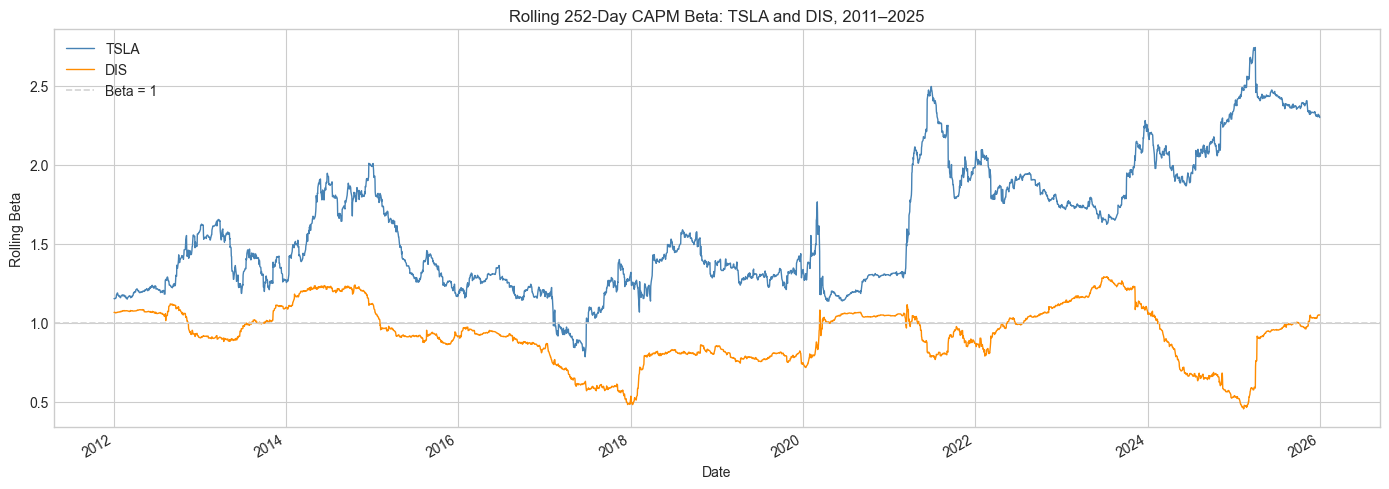

In [100]:
# Rolling 252-day CAPM beta via covariance/variance formulation
tsla_rolling_cov = data['tsla_ex'].rolling(252).cov(data['Mkt-RF'])
dis_rolling_cov  = data['dis_ex'].rolling(252).cov(data['Mkt-RF'])
mkt_rolling_var  = data['Mkt-RF'].rolling(252).var()

tsla_rolling_beta = tsla_rolling_cov / mkt_rolling_var
dis_rolling_beta  = dis_rolling_cov  / mkt_rolling_var

fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(data.index, tsla_rolling_beta, color='steelblue',  linewidth=1,   label='TSLA')
ax.plot(data.index, dis_rolling_beta,  color='darkorange', linewidth=1,   label='DIS')
ax.axhline(1.0, color='lightgray', linewidth=1.2, linestyle='--', label='Beta = 1')

ax.set_title('Rolling 252-Day CAPM Beta: TSLA and DIS, 2011–2025')
ax.set_xlabel('Date')
ax.set_ylabel('Rolling Beta')
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.xaxis.set_major_locator(mdates.YearLocator(2))
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

### 2. Interpretation of Time-Varying Beta

**TSLA** TSLA's rolling beta is highly unstable across the sample period, with documented swings between sub-1.0 readings in its earlier years as a smaller-cap growth story and values well above 2.0 during the 2020–2021 speculative growth rally when near-zero interest rates inflated high-multiple stocks and TSLA became one of the most widely traded names in the market. The COVID-19 shock in March 2020 produced a pronounced spike in TSLA's rolling beta, a standard crisis-period effect where cross-asset correlations converge as investors liquidate across the board during a liquidity event. The 2022 rate-hike cycle also left TSLA's beta elevated and volatile: as the Federal Reserve's aggressive tightening compressed the present value of long-horizon earnings, TSLA's high-multiple valuation amplified the drawdown relative to the broader market. This instability is a well-known characteristic of TSLA; the changing composition of its investor base (index funds, retail traders, hedge funds) over its extraordinary growth in market capitalization generates a beta that reflects who is holding the stock at any given moment as much as the fundamental business risk.

**DIS** DIS's rolling beta is substantially more stable, tracking near 1.0 for the majority of the sample with relatively moderate deviations. The beta moves around business-specific stress periods, including cable-TV disruption in the late 2010s, the integration period around Disney's majority acquisition of 21st Century Fox, and renewed concerns in 2025 about TV decline, macroeconomic pressure, and profitability growth. The March 2020 COVID-19 shock is visible as a transient beta spike, amplified for DIS by the simultaneous physical closure of its theme parks, an idiosyncratic revenue disruption layered atop the market-wide panic. Outside of these short-lived periods, DIS's rolling beta drifts within a relatively narrow band, consistent with a mature large-cap consumer-entertainment company whose cash flows move broadly with the economic cycle at roughly a one-for-one rate.

**Divergence** The two rolling betas diverge persistently, particularly from 2020 onward, rather than moving together. This confirms that TSLA and DIS occupy very different positions on the systematic-risk spectrum and that the higher full-sample TSLA beta estimated in Sections 3 and 4 is not an artifact of a few outlier periods but reflects a durably higher market sensitivity over most of the sample. The sole exception is the acute COVID-19 shock in spring 2020, where both betas spike simultaneously, the expected result during a systemic liquidity event where all risky assets become temporarily more correlated with the market.

### 3. Residual Stationarity (ADF on FF3 Residuals)

A well-specified linear model applied to stationary data should produce stationary residuals. Failure to reject the unit-root null in FF3 residuals would indicate a structural misspecification, for instance an omitted common factor or a cointegrating relationship not captured by the three Fama-French factors. The ADF test is applied to both sets of FF3 residuals to verify that the model satisfies this minimum requirement.

In [101]:
def adf_resid(resid, name):
    result = adfuller(resid)
    return {
        'Stock': name,
        'ADF Statistic': round(result[0], 4),
        'p-value': round(result[1], 6)
    }

adf_ff3_df = pd.DataFrame([
    adf_resid(ff3_tsla.resid, 'TSLA'),
    adf_resid(ff3_dis.resid,  'DIS'),
])

print('ADF Test on FF3 Residuals:')
print(adf_ff3_df.to_string(index=False))

ADF Test on FF3 Residuals:
Stock  ADF Statistic  p-value
 TSLA       -34.9442      0.0
  DIS       -35.8171      0.0


Both FF3 residual series reject the unit-root null at a p-value indistinguishable from zero. This is the expected result: regressing stationary excess returns on stationary factor returns should produce stationary residuals unless a structural nonlinearity or cointegrating relationship is present. The strongly negative ADF statistics confirm no such anomaly; the FF3 model leaves no integrated component in the residuals, and inference on factor loadings is not contaminated by spurious correlation driven by shared stochastic trends.

### 4. Residual Autocorrelation

ACF and PACF plots of the FF3 residuals test whether serial dependence remains in the levels of the residual series after removing the three Fama-French factors. ACF plots of *squared* FF3 residuals then test whether the volatility clustering identified in Section 2.4 for raw returns persists in the factor-adjusted residuals, that is, whether the effects are idiosyncratic or factor-driven.

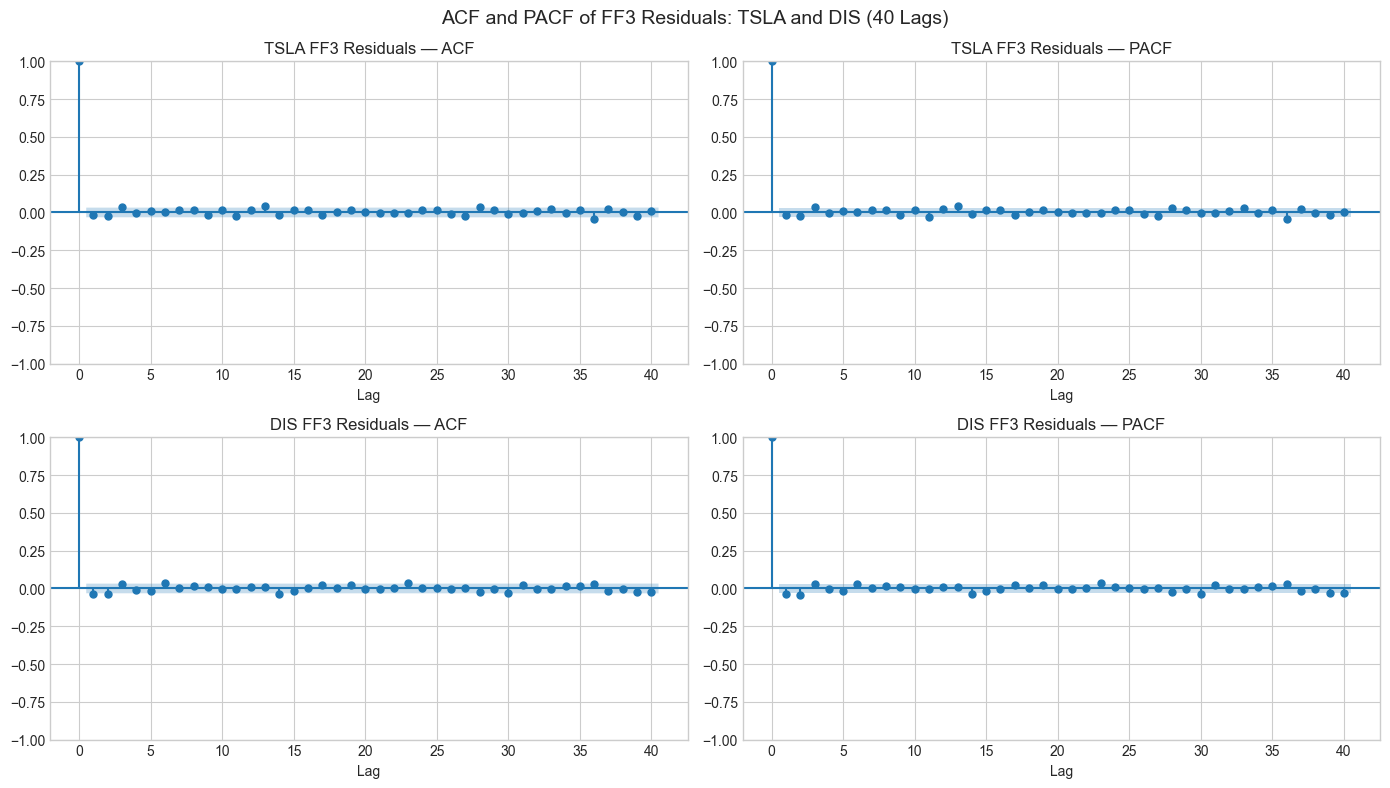

In [102]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

plot_acf( ff3_tsla.resid, lags=40, ax=axes[0, 0], title='TSLA FF3 Residuals — ACF')
plot_pacf(ff3_tsla.resid, lags=40, ax=axes[0, 1], title='TSLA FF3 Residuals — PACF')
plot_acf( ff3_dis.resid,  lags=40, ax=axes[1, 0], title='DIS FF3 Residuals — ACF')
plot_pacf(ff3_dis.resid,  lags=40, ax=axes[1, 1], title='DIS FF3 Residuals — PACF')

for ax in axes.flat:
    ax.set_xlabel('Lag')

fig.suptitle('ACF and PACF of FF3 Residuals: TSLA and DIS (40 Lags)', fontsize=14)
plt.tight_layout()
plt.show()

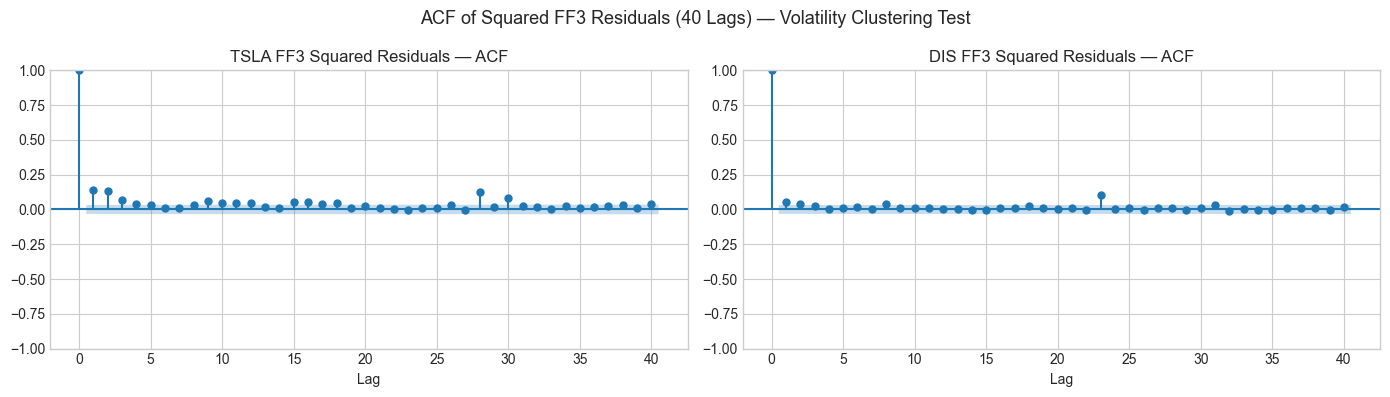

In [103]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

plot_acf(ff3_tsla.resid ** 2, lags=40, ax=axes[0], title='TSLA FF3 Squared Residuals — ACF')
plot_acf(ff3_dis.resid  ** 2, lags=40, ax=axes[1], title='DIS FF3 Squared Residuals — ACF')

for ax in axes:
    ax.set_xlabel('Lag')

fig.suptitle('ACF of Squared FF3 Residuals (40 Lags) — Volatility Clustering Test', fontsize=13)
plt.tight_layout()
plt.show()

**Levels (ACF and PACF of residuals):** The FF3 residuals in levels show at most isolated, marginally significant autocorrelations, broadly consistent with mean white noise. Removing the three Fama-French factors eliminates the systematic mean-return components attributable to market, size, and value exposures, leaving a residual series without meaningful serial dependence in its levels. This is the expected finding under a well-specified factor model: if FF3 fully characterizes expected excess returns, the residuals should be approximately serially uncorrelated at the daily frequency.

**Squared residuals (volatility clustering):** The ACF of squared FF3 residuals tells a starkly different story. Both TSLA and DIS exhibit statistically significant, slowly decaying autocorrelation in their squared residuals across many of the 40 lags, a pattern similar in character to the squared raw return ACFs from Section 2.4. Removing the three Fama-French factors does not materially reduce volatility clustering: the factors explain the *conditional mean* of excess returns but have no effect on the *conditional variance* dynamics. This confirms that Autoregressive Conditional Heteroskedasticity (ARCH) effects in these stocks are primarily idiosyncratic, driven by each stock's own variance process, rather than factor-driven. The persistence of volatility clustering in FF3 residuals motivates Generalized Autoregressive Conditional Heteroskedasticity (GARCH) models for characterizing the variance dynamics; such models are beyond the scope of this analysis but represent the natural next step for a complete description of daily return risk.

### 5. Putting It Together

**Tesla (TSLA)** Time-series analysis revealed TSLA as a high-volatility, fat-tailed return series with persistent and strong volatility clustering; rolling annualized vol regularly exceeds 80% during stress periods and the squared-return ACF decays slowly across many lags, both characteristic of a stock with a highly active and sentiment-driven investor base. Under CAPM, TSLA carries a market beta well above 1.0, classifying it as an aggressive stock that amplifies broad market movements; the FF3 model confirms this and adds a positive SMB loading (reflecting its small/mid-cap origins and speculative co-movement with growth stocks) and a strongly negative HML loading, the defining signature of a high-multiple growth stock whose valuation is driven by future earnings expectations rather than current book value. Both CAPM and FF3 produce statistically significant positive alpha for TSLA, a backward-looking reflection of its extraordinary realized appreciation over the full 2011–2025 sample rather than evidence of reliable future abnormal returns. The rolling beta analysis demonstrates that TSLA's systematic risk is highly unstable over time, oscillating across a wide range depending on the prevailing interest-rate and sentiment environment, so the full-sample unconditional beta masks substantial temporal variation that a static risk estimate cannot convey. After FF3 adjustment, TSLA's residuals are approximately uncorrelated in levels but exhibit persistent volatility clustering in their squared values: the linear factor model captures TSLA's mean return structure but leaves the conditional variance dynamics unexplained, pointing to GARCH-family models as the natural extension.

**Disney (DIS)** DIS presents a substantially different risk profile across every dimension examined. Its daily return volatility is meaningfully lower than TSLA's throughout the sample, and while it also displays volatility clustering and fat tails, the near-universal properties of daily equity returns, the clustering decays faster and tail thickness is less extreme. Under CAPM, DIS's market beta is close to 1.0, indicating that it tracks broad market movements at roughly a one-for-one rate, neither amplifying nor dampening systematic risk; no significant CAPM alpha is detectable. The FF3 model characterizes DIS as a value-tilted large-cap stock: its positive and significant HML loading (+0.229) reflects Disney's asset-heavy operations and mature cash-flow profile, while its near-zero and insignificant SMB loading confirms its stable large-cap classification. DIS's rolling beta is considerably more stable than TSLA's, remaining close to the 1.0 reference line for most of the sample with only transient deviations, confirming that the full-sample CAPM beta is a useful summary of its systematic risk. The FF3 residuals for DIS are approximately uncorrelated in levels and show no significant alpha, confirming adequate mean-model specification, but the squared residual ACF retains strong persistence, confirming that conditional heteroskedasticity is an intrinsic property of DIS's idiosyncratic return process that no linear factor model can eliminate.

## Conclusion

This analysis characterized the risk profiles of Tesla (TSLA) and Disney (DIS) over the January 2011 – December 2025 period using CAPM, the Fama-French three-factor model, and supporting time-series diagnostics. The two stocks occupy sharply different positions on the risk spectrum: TSLA is a high-beta, speculative-growth stock with a strongly negative HML loading, highly unstable rolling beta, and statistically significant positive alpha reflecting its extraordinary realized appreciation over the sample; DIS is a near-market-beta, value-tilted large-cap conglomerate with a stable near-unity beta, positive HML exposure rooted in its asset-heavy business profile, and no detectable alpha after three-factor adjustment. Both stocks exhibit persistent ARCH-type volatility clustering in their FF3 residuals, confirming that the three-factor linear model characterizes the mean structure of daily excess returns but leaves conditional variance dynamics unmodeled, a structural limitation motivating GARCH-family extensions for any application requiring accurate characterization of time-varying idiosyncratic risk. Together, TSLA and DIS illustrate how the Fama-French framework captures economically meaningful cross-sectional differences in risk exposure while also exposing the boundaries of what static linear models can describe about the dynamic behavior of daily equity returns.